In [1]:
import imageio
import imageio.v3 as iio
import random
import matplotlib.pyplot as plt
import numpy

In [2]:
# imageio.plugins.freeimage.download()  # Needed for .hdr images
im = iio.imread(r"C:\dev\scratch\buikslotermeerplein_4k.hdr")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..28.625].


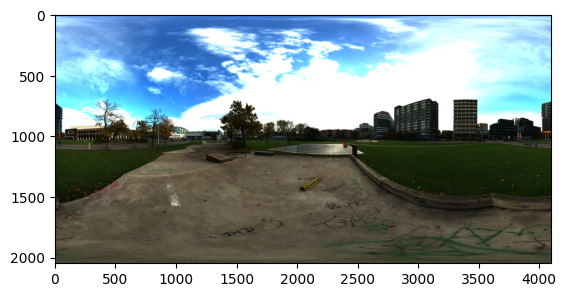

In [3]:
plt.imshow(im)

In [4]:
# 2D array to hold luminence "distribution"
d = numpy.full((2048,4096), 0.0, dtype=numpy.float32)
d.shape

(2048, 4096)

In [5]:
# Calculate luminence distribution from array
for i in range(im.shape[0]):
    for j in range(im.shape[1]):
        d[i][j] = im[i][j][0] * 0.2126 + im[i][j][1] * 0.7152 + im[i][j][2] * 0.0722
 

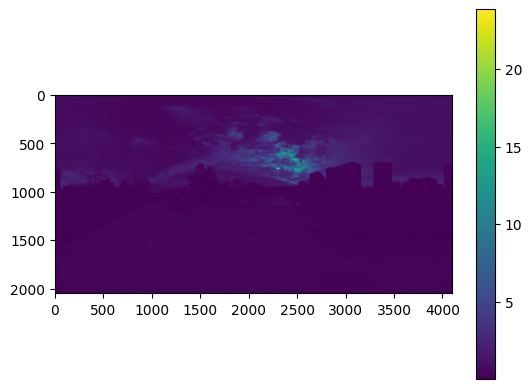

In [6]:
plt.imshow(d)
plt.colorbar()

In [7]:
nu, nv = d.shape
nu,nv

(2048, 4096)

In [8]:
conditional_cdfs = numpy.full((d.shape[1], d.shape[0] + 1), -1, dtype=numpy.float32)
funcInts = numpy.full(d.shape[1], -1, dtype=numpy.float32)

In [9]:
min = 0 #numpy.min(d)
max = 1 #numpy.max(d)
maxmindelta = max - min
abs_d = numpy.abs(d)

# Calculate CDFs for each column in the image ( conditional CDFs. Conditional, because they're conditional on getting picked as the x column )
# Save the integral of each cdf, for later creating the marginal CDF
for v in range(nv):   # Looping over x ( over columns )
    cdf = conditional_cdfs[v]
    cdf[0] = 0
    for i in range(1, nu + 1): # Looping over y ( over numbers in a column )
        cdf[i] = cdf[i - 1] + abs_d[i-1][v] * maxmindelta / nu
    funcInts[v] = cdf[nu]
    if funcInts[v] == 0:
        for i in range(1, nu + 1):
            cdf[i] = i / nu
    else:
        for i in range(1, nu + 1):
            cdf[i] /= funcInts[v]


In [19]:
abs_d[0:100]

array([[0.54578906, 0.54578906, 0.54578906, ..., 0.54578906, 0.54578906,
        0.54578906],
       [0.5521867 , 0.5521867 , 0.5521867 , ..., 0.5521867 , 0.5521867 ,
        0.5521867 ],
       [0.556657  , 0.556657  , 0.556657  , ..., 0.556657  , 0.556657  ,
        0.556657  ],
       ...,
       [0.8168828 , 0.8191484 , 0.823075  , ..., 0.8130281 , 0.81468904,
        0.81635   ],
       [0.81522185, 0.8119    , 0.81582654, ..., 0.8185844 , 0.8202453 ,
        0.81522185],
       [0.80740935, 0.81299686, 0.80574846, ..., 0.8085469 , 0.80518436,
        0.8090703 ]], dtype=float32)

In [18]:
funcInts

array([10.079583, 10.033856, 10.03979 , ..., 10.098433, 10.072427,
       10.031988], dtype=float32)

In [10]:
conditional_cdfs[0][300:310]

array([0.27718642, 0.27812177, 0.27905777, 0.28000727, 0.2809645 ,
       0.28194562, 0.2829138 , 0.2838646 , 0.2848129 , 0.28575665],
      dtype=float32)

In [11]:
funcInts[115:125]

array([14.325313, 14.32197 , 14.28631 , 14.281452, 14.122415, 13.896679,
       13.902482, 13.883525, 13.883223, 13.873373], dtype=float32)

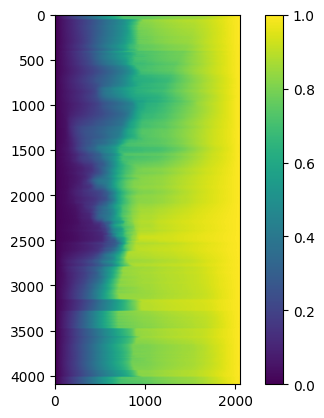

In [12]:
plt.imshow(conditional_cdfs)
plt.colorbar()

In [13]:
marginal_cdf = numpy.full(nv + 1, -1, dtype=numpy.float32)

In [14]:
min = 0 #numpy.min(funcInts)
max = 1 #numpy.max(funcInts)
maxmindelta = max - min
abs_funcInts = numpy.abs(funcInts)

# Create margial CDF, with integral from each conditional CDF
marginal_cdf[0] = 0
for i in range(1, nv + 1):
    marginal_cdf[i] = marginal_cdf[i - 1] + abs_funcInts[i-1] * maxmindelta / nv
marginal_funcint = marginal_cdf[nv]
if marginal_funcint == 0:
    for i in range(1, nv + 1):
        marginal_cdf[i] = i / nv
else:
    for i in range(1, nv + 1):
        marginal_cdf[i] /= marginal_funcint

In [17]:
marginal_funcint

526.149

In [15]:
number_of_samples = 500
samples = numpy.full((2,number_of_samples), -1, dtype=numpy.float32)


for j in range(number_of_samples):

    (u, v) = (random.random(), random.random()) # Uniformally distributed random numbers

    (fx, fy) = (-1, -1)

    pdf = -1

    # Sample Marginal CDF, find x coord
    for i in range(marginal_cdf.shape[0]):
        if u >= marginal_cdf[i]:
            fx = i - 1
        else:
            break   

    marg_pdf = abs_funcInts[fx] / marginal_funcint if marginal_funcint > 0 else 0

    # Sample Conditional CDF, find y coord
    for i in range(conditional_cdfs[fx].shape[0]):
        if v >= conditional_cdfs[fx][i]:
            fy = i - 1
        else:
            break

    cond_pdf = abs_d[fy][fx] / funcInts[fx]

    # Probability of sampling this point, used to weight light sample
    pdf = marg_pdf * cond_pdf
    print(f"{marg_pdf=}   {cond_pdf=}   {pdf=}")

    # Store Sample locations
    samples[0][j] = fx
    samples[1][j] = fy
    #samples[pdf][j] = pdf

    #print(f"{fx=} | {fy=} | {pdf=} luminance={d[fy][fx]}")

marg_pdf=0.03998404   cond_pdf=0.1818518   pdf=0.0072711697
marg_pdf=0.04255892   cond_pdf=0.04791512   pdf=0.0020392158
marg_pdf=0.0421945   cond_pdf=0.17599009   pdf=0.007425814
marg_pdf=0.024516338   cond_pdf=0.0224773   pdf=0.0005510611
marg_pdf=0.030524194   cond_pdf=0.17423795   pdf=0.005318473
marg_pdf=0.026790474   cond_pdf=0.030889785   pdf=0.000827552
marg_pdf=0.043184355   cond_pdf=0.14573331   pdf=0.0062933993
marg_pdf=0.047246385   cond_pdf=0.048766498   pdf=0.0023040408
marg_pdf=0.02242622   cond_pdf=0.040339254   pdf=0.00090465695
marg_pdf=0.0652044   cond_pdf=0.42197958   pdf=0.027514923
marg_pdf=0.057864927   cond_pdf=0.25494224   pdf=0.014752214
marg_pdf=0.050769176   cond_pdf=0.021154027   pdf=0.0010739726
marg_pdf=0.021906964   cond_pdf=0.027828004   pdf=0.0006096271
marg_pdf=0.02164653   cond_pdf=0.027241888   pdf=0.0005896923
marg_pdf=0.018392256   cond_pdf=0.09322782   pdf=0.0017146699
marg_pdf=0.02217502   cond_pdf=0.07929557   pdf=0.0017583808
marg_pdf=0.073973

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..28.625].


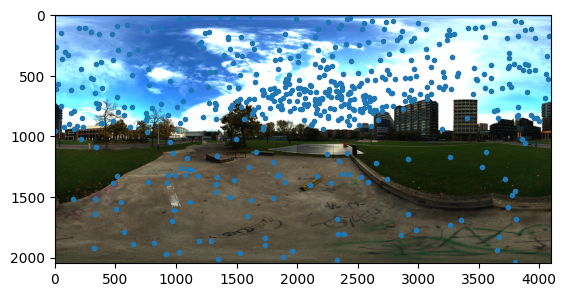

In [16]:
plt.imshow(im)
plt.scatter(samples[0], samples[1], marker='.')

In [17]:
marginal_cdf[-10:-1]

array([0.99865574, 0.99880654, 0.99895746, 0.99910873, 0.99926   ,
       0.99941057, 0.99955827, 0.9997059 , 0.99985325], dtype=float32)

: 